# Retrain model

In [1]:
import pandas as pd
from blocksnet.enums import LandUse

blocks_gdf = pd.read_pickle('./../data/saint_petersburg/blocks.pickle')
for lu in LandUse:
    blocks_gdf[lu.value] = blocks_gdf[lu.value].clip(lower=0, upper=1)
blocks_gdf = blocks_gdf[blocks_gdf.area > 0]

Убираем всякие экстремальные значения

In [2]:
from sklearn.ensemble import IsolationForest

clf = IsolationForest(contamination=0.01, random_state=42)
blocks_gdf['outlier'] = clf.fit_predict(blocks_gdf[['site_area', 'build_floor_area', 'footprint_area', 'living_area']])
blocks_gdf = blocks_gdf[blocks_gdf['outlier'] != -1].copy()

In [3]:
from blocksnet.relations import generate_adjacency_graph

graph = generate_adjacency_graph(blocks_gdf, 10)

2025-10-27 22:01:43.691 | INFO     | blocksnet.relations.adjacency.core:_generate_adjacency_nodes:9 - Generating nodes
2025-10-27 22:01:43.696 | INFO     | blocksnet.relations.adjacency.core:_generate_adjacency_edges:14 - Generating edges
2025-10-27 22:01:46.458 | SUCCESS  | blocksnet.relations.adjacency.core:generate_adjacency_graph:37 - Adjacency graph successfully generated: 9437 nodes, 29697 edges


## Init things

In [4]:
from model import MultiScaleGNN
from sklearn.preprocessing import StandardScaler
from blocksnet.machine_learning.strategy.torch import TorchGraphImputationStrategy
from blocksnet.preprocessing.imputing.development import DevelopmentImputer

strategy_params = {
    'hidden_dim': 128,
    'num_layers': 1,
    'dropout': 0.2,
}

strategy = TorchGraphImputationStrategy(
    MultiScaleGNN, 
    strategy_params, 
    scalers={'x': StandardScaler(), 'y': StandardScaler()}
)

imputer = DevelopmentImputer(strategy)

## Train

In [5]:
from torch import nn

train_params = {
    'epochs': 5_000,
    'optimizer_params': {
        "lr": 1e-4,
        "weight_decay": 1e-4
    },
    'criterion_cls': nn.SmoothL1Loss
}

train_losses, test_losses = imputer.train(blocks_gdf, graph, train_params=train_params)

Train loss: 0.11527 | Test loss: 0.06175: 100%|██████████| 5000/5000 [00:49<00:00, 101.88it/s]


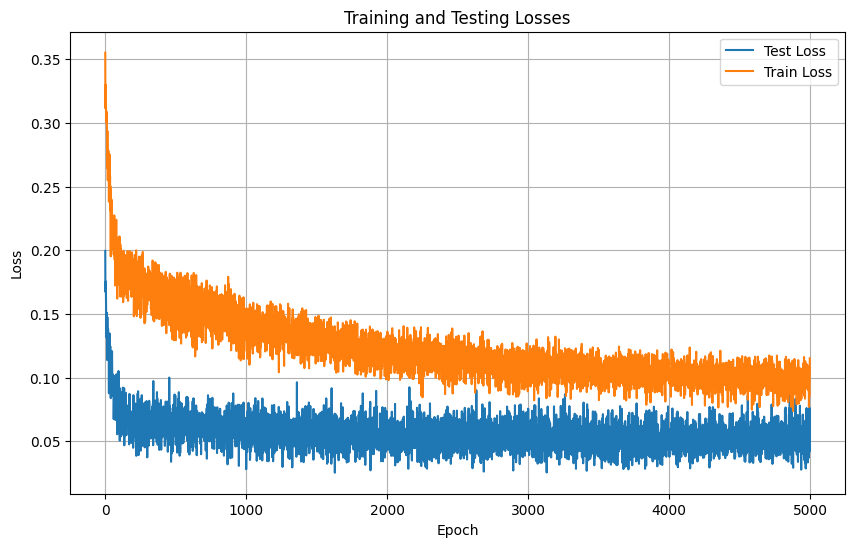

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(test_losses, label='Test Loss')
plt.plot(train_losses, label='Train Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Testing Losses')
plt.legend()
plt.grid(True)
plt.show()

In [7]:
imputer.strategy.save('gnn')

In [8]:
RATE = 0.5
n = round(len(blocks_gdf) * RATE)
blocks_ids = blocks_gdf.sample(n).index.to_list()

df_pred = imputer.run(blocks_gdf, graph, blocks_ids).loc[blocks_ids].copy()
df_true = blocks_gdf.loc[df_pred.index, df_pred.columns].copy()

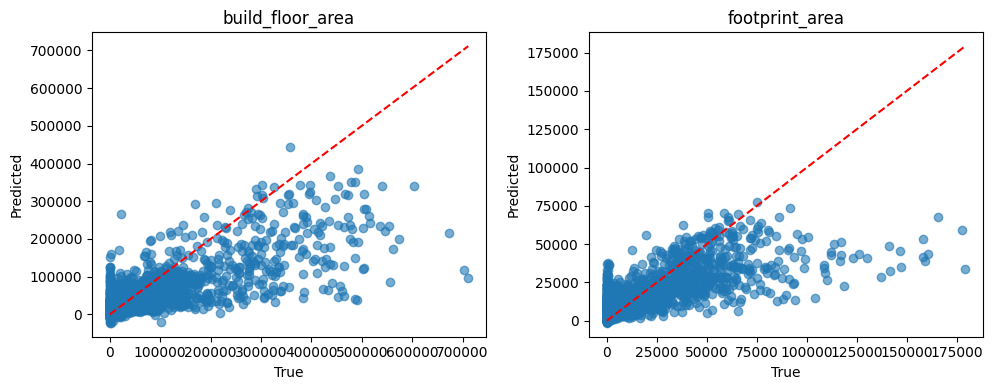

In [9]:
import matplotlib.pyplot as plt

columns = df_pred.columns
n_cols = 3  # сколько графиков в строке
n_rows = (len(columns) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 4*n_rows))
axes = axes.flatten()

for i, col in enumerate(columns):
    ax = axes[i]
    y_true = df_true[col].values
    y_pred = df_pred[col].values
    
    ax.scatter(y_true, y_pred, alpha=0.6)
    ax.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'r--')  # y=x
    ax.set_xlabel('True')
    ax.set_ylabel('Predicted')
    ax.set_title(col)

# если графиков меньше, чем ячеек, убираем лишние оси
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()